# Exploratory Data Analysis

##### Understand the data, discover patterns, and generate business insights—not just charts.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Basic bussiness question⭐⭐⭐⭐⭐

##### total orders, total revenue, total profit ans total customers

In [6]:
df = pd.read_csv('Feature_extracted_data.csv', encoding='latin1')

In [7]:
print("Total Orders:", df['Order Id'].nunique())

print("Total Revenue: $", round(df['Sales'].sum(),2))

print("Total Profit: $", round(df['Order Profit Per Order'].sum(),2))

print("Total Customers:", df['Customer Id'].nunique())

Total Orders: 65752
Total Revenue: $ 36784735.01
Total Profit: $ 3966902.97
Total Customers: 20652


## Monthly Sales Trend ⭐⭐⭐⭐⭐

In [9]:
#highest sales by month
monthly_sales = (
    round(df.groupby('Order Month')['Sales']
      .sum(),2)
      .sort_values(ascending=False)
)

monthly_sales

Order Month
January      3459246.47
July         3188170.17
August       3187032.11
May          3185363.96
October      3171278.99
September    3164510.75
March        3125111.59
June         3059152.21
April        3053996.48
February     2888087.65
November     2703624.77
December     2599159.87
Name: Sales, dtype: float64

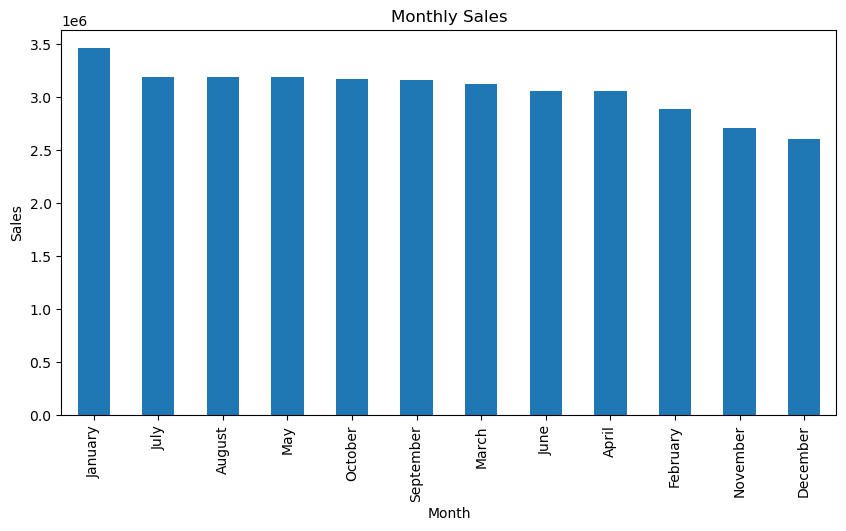

In [10]:
monthly_sales.plot(kind='bar', figsize=(10,5))

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [12]:
#profit by category
category_profit = (
    df.groupby('Category Name')['Order Profit Per Order']
      .sum()
      .sort_values(ascending=False)
)

category_profit.head(10)

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Name: Order Profit Per Order, dtype: float64

In [14]:
#sales by category 
category_sales = (
    df.groupby('Category Name')['Sales']
      .sum()
      .sort_values(ascending=False)
)

category_sales.head(10)

Category Name
Fishing                 6.929654e+06
Cleats                  4.431943e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113845e+06
Men's Footwear          2.891758e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309522e+06
Computers               6.630000e+05
Name: Sales, dtype: float64

In [15]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [16]:
category_sales.head(10)

Category Name
Fishing                6,929,653.69
Cleats                 4,431,942.78
Camping & Hiking       4,118,425.57
Cardio Equipment       3,694,843.20
Women's Apparel        3,147,800.00
Water Sports           3,113,844.68
Men's Footwear         2,891,757.66
Indoor/Outdoor Games   2,888,993.91
Shop By Sport          1,309,522.04
Computers                663,000.00
Name: Sales, dtype: float64

In [19]:
#shipping mode 
df['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

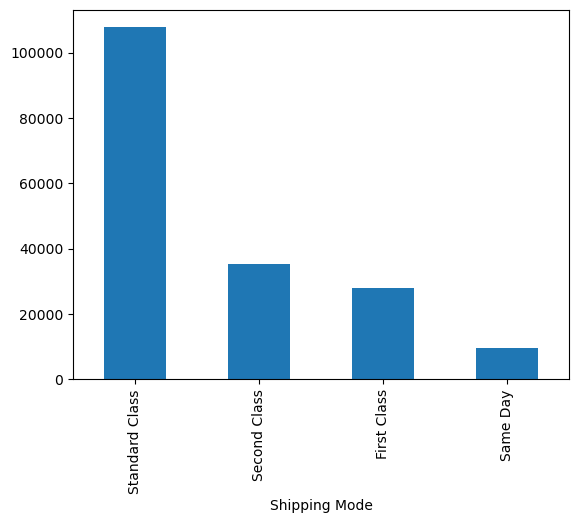

In [20]:
df['Shipping Mode'].value_counts().plot(kind='bar')
plt.show()

In [21]:
#late deliveries
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

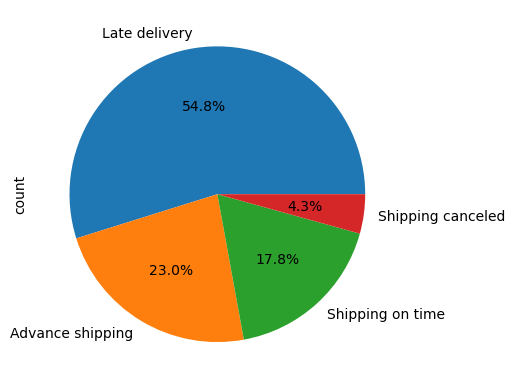

In [22]:
df['Delivery Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [24]:
#customer segments 
segment_sales = (
    df.groupby('Customer Segment')['Sales']
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Customer Segment
Consumer      19,095,790.16
Corporate     11,168,406.84
Home Office    6,520,538.02
Name: Sales, dtype: float64

In [25]:
#top products
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Field & Stream Sportsman 16 Gun Fire Safe       6,929,653.69
Perfect Fitness Perfect Rip Deck                4,421,143.14
Diamondback Women's Serene Classic Comfort Bi   4,118,425.57
Nike Men's Free 5.0+ Running Shoe               3,667,633.20
Nike Men's Dri-FIT Victory Golf Polo            3,147,800.00
Pelican Sunstream 100 Kayak                     3,099,845.09
Nike Men's CJ Elite 2 TD Football Cleat         2,891,757.66
O'Brien Men's Neoprene Life Vest                2,888,993.91
Under Armour Girls' Toddler Spine Surge Runni   1,269,082.67
Dell Laptop                                       663,000.00
Name: Sales, dtype: float64

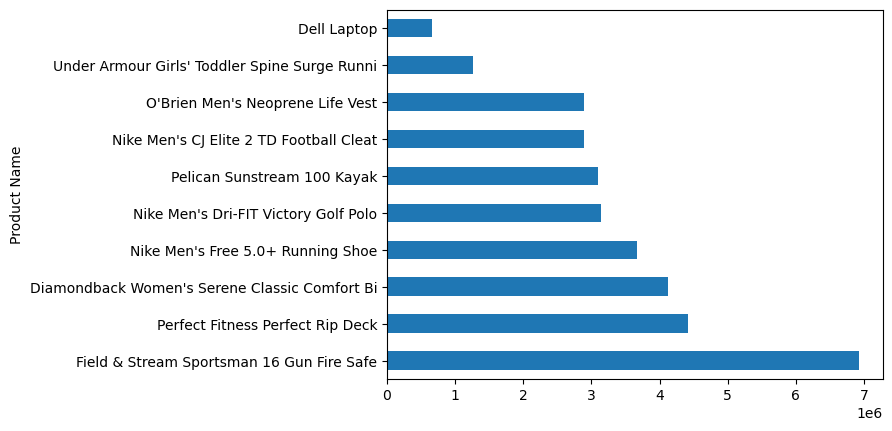

In [27]:
top_products.plot(kind='barh')
plt.show()

In [28]:
#market analysis 
market_sales = (
    df.groupby('Market')['Sales']
      .sum()
      .sort_values(ascending=False)
)

market_sales

Market
Europe         10,872,396.80
LATAM          10,277,612.84
Pacific Asia    8,273,743.74
USCA            5,066,528.71
Africa          2,294,452.93
Name: Sales, dtype: float64

In [29]:
#correlation analysis 
numeric = df.select_dtypes(include=np.number)

In [30]:
corr = numeric.corr()

corr

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Department Id,Latitude,Longitude,...,Order Profit Per Order,Product Card Id,Product Category Id,Product Price,Order Year,Order Quarter,Shipping Time,Shipping Delay,Profit Margin (%),Calculated Discount
Days for shipping (real),1.00,0.52,-0.01,0.00,0.40,-0.00,0.00,-0.00,-0.00,0.00,...,-0.01,-0.00,-0.00,0.00,0.00,-0.01,1.00,0.61,-0.00,0.00
Days for shipment (scheduled),0.52,1.00,-0.00,0.01,-0.37,-0.00,0.00,-0.00,-0.01,0.00,...,-0.00,-0.00,-0.00,0.01,0.00,-0.01,0.53,-0.36,-0.00,0.00
Benefit per order,-0.01,-0.00,1.00,0.13,-0.00,0.03,0.01,0.03,0.00,-0.00,...,1.00,0.03,0.03,0.10,0.01,0.01,-0.00,-0.01,0.83,0.07
Sales per customer,0.00,0.01,0.13,1.00,-0.00,0.23,0.06,0.23,-0.00,0.00,...,0.13,0.24,0.23,0.78,0.06,0.06,0.00,-0.00,0.00,0.50
Late_delivery_risk,0.40,-0.37,-0.00,-0.00,1.00,0.00,0.00,0.00,0.00,-0.00,...,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.38,0.78,-0.00,-0.00
Category Id,-0.00,-0.00,0.03,0.23,0.00,1.00,0.27,0.89,0.00,-0.00,...,0.03,0.99,1.00,0.46,0.18,0.07,-0.00,-0.00,-0.00,0.14
Customer Id,0.00,0.00,0.01,0.06,0.00,0.27,1.00,0.14,0.00,-0.01,...,0.01,0.23,0.27,0.11,0.19,0.06,0.00,0.00,-0.00,0.04
Department Id,-0.00,-0.00,0.03,0.23,0.00,0.89,0.14,1.00,0.00,-0.00,...,0.03,0.91,0.89,0.45,0.10,0.05,-0.00,-0.00,-0.00,0.15
Latitude,-0.00,-0.01,0.00,-0.00,0.00,0.00,0.00,0.00,1.00,-0.53,...,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00
Longitude,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.01,-0.00,-0.53,1.00,...,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.01,0.00,-0.00,0.00


In [31]:
#top countries 
country_sales = (
    df.groupby('Order Country')['Sales']
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

Order Country
Estados Unidos   4,879,667.67
Francia          2,879,942.36
MÃÂ©xico        2,633,195.29
Alemania         2,074,171.82
Australia        1,694,621.67
Reino Unido      1,612,094.85
Brasil           1,594,319.95
China            1,172,902.11
Italia           1,072,181.67
India              962,396.70
Name: Sales, dtype: float64

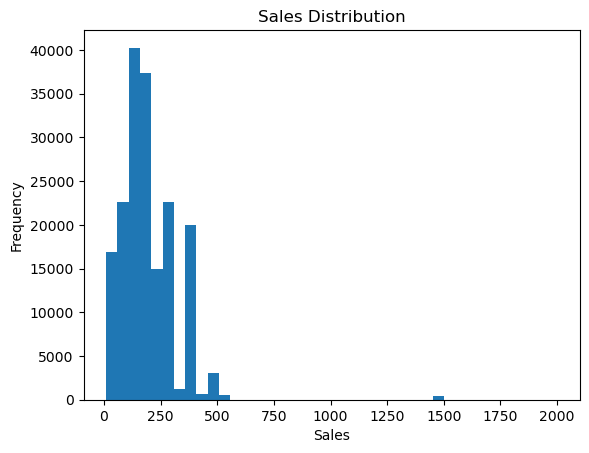

In [33]:
#sales dashboard 
plt.hist(df['Sales'], bins=40)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()